# Problem description
The state variables are        $
x = \begin{bmatrix}x\\ y\\ \phi \\ \theta \end{bmatrix}
$ $\quad$
$
u = \begin{bmatrix}v_x\\ \omega \\ v \end{bmatrix}
$

$$
\dot{x} = \begin{bmatrix}v_x\cos\phi \\ v_x\sin\phi \\ \omega \\ v \end{bmatrix}
$$

The path will be parametized by $\begin{bmatrix} x_d(\theta) \\ y_d(\theta) \end{bmatrix}$

We define the path parameter $\theta$ and corresponding path points:
- $x_d(\theta)$ = spline-interpolated x-coordinate  
- $y_d(\theta)$ = spline-interpolated y-coordinate
- $\phi(\theta) = \arctan\left(\frac{y_d'(\theta)}{x_d'(\theta)}\right)$ (path tangent angle)

The contouring and lag errors are:
- $\varepsilon_c = \sin(\phi(\theta))(x - x_d(\theta)) - \cos(\phi(\theta))(y - y_d(\theta))$ (perpendicular to path)
- $\varepsilon_l = -\cos(\phi(\theta))(x - x_d(\theta)) - \sin(\phi(\theta))(y - y_d(\theta))$ (along path direction)

We want to minimize:
$$
q_c\varepsilon_c^2 + q_l\varepsilon_l^2 - q_\theta\theta + \mathbf{u}^T\mathbf{Q}\mathbf{u}
$$

where $\theta$ is now an optimization variable representing progress along the waypoint sequence.

## Problems

1. If I don't set a limit for v(how fast can theta be changed), the controller try to cheat by commanding a high v to just get the progress reward early on. This is problematic if we want to make the robot follow overlapping circles as it will just want to cheat by jumping the progress and ending the path early

In [9]:
# Import necessary libraries
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import FancyArrow, Circle

In [10]:
# Dynamics and integration
# Dynamics definition

# States
x = ca.MX.sym('x') # type: ignore
y = ca.MX.sym('y') # type: ignore
phi = ca.MX.sym('phi') # type: ignore
theta = ca.MX.sym('theta') # type: ignore

# Inputs
v_x = ca.MX.sym('v_x') # type: ignore
omega = ca.MX.sym('omega') # type: ignore
v = ca.MX.sym('v') # type: ignore

state = ca.vertcat(x, y, phi, theta)
control = ca.vertcat(v_x, omega, v)

ode = ca.vertcat(
    v_x * ca.cos(phi),  # x_dot
    v_x * ca.sin(phi),  # y_dot  
    omega,              # phi_dot
    v,                  # virtual_speed
)

# Dynamics defined
f = ca.Function('f', [state, control], [ode], ['x', 'u'], ['ode'])

f

Function(f:(x[4],u[3])->(ode[4]) MXFunction)

## Use RK4 To discretize the system dynamics

In [11]:
N = 10  # Prediction horizon (number of time steps)
T = 0.05  # Sampling time
# Integrator options
intg_options = {
    'simplify': True,
    'number_of_finite_elements': 4
}

dae = {
    'x': state,      # What are states?
    'p': control,      # What are parameters (fixed during integration horizon)?
    'ode': f(state, control)   # Expression for the right-hand side
}
# integrator(str name, str solver, Function dae, float t0, [float] tout, dict opts) -> Function
intg = ca.integrator('intg', 'rk', dae, 0, T*N, intg_options)
x_next = intg(x0=state, p=control)['xf']

# Big F, the discretized function
F = ca.Function('F', [state, control], [x_next], ['x', 'u'], ['x_next'])
F

Function(F:(x[4],u[3])->(x_next[4]) MXFunction)

In [12]:
sim = F.mapaccum(N)
sim

Function(F_acc10:(x[4],u[3x10])->(x_next[4x10]) MXFunction)

In [13]:

U = ca.MX.sym('U', 3, N) # type: ignore
U

MX(U)

# Solve for problem

## Define path

In [32]:
from scipy.interpolate import interp1d

class WaypointPathMPC:
    def __init__(self, waypoints):
        """
        waypoints: Nx2 array of [x, y] coordinates
        """
        self.original_waypoints = waypoints
        self.setup_optimized_path()

    def setup_optimized_path(self):
        """Pre-compute path representation for fast MPC evaluation"""
        waypoints = self.original_waypoints

        # Compute cumulative distances for arc-length parameterization
        distances = np.sqrt(np.sum(np.diff(waypoints, axis=0) ** 2, axis=1))
        cumulative_distances = np.concatenate([[0], np.cumsum(distances)])
        total_distance = cumulative_distances[-1]

        # Normalize to [0, 1]
        s_waypoints = cumulative_distances / total_distance

        # Create high-resolution lookup table
        N_lookup = 1000
        s_lookup = np.linspace(0, 1, N_lookup)

        # Interpolate waypoints to create dense path
        x_interp = interp1d(
            s_waypoints,
            waypoints[:, 0],
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )
        y_interp = interp1d(
            s_waypoints,
            waypoints[:, 1],
            kind="linear",
            bounds_error=False,
            fill_value="extrapolate",
        )

        x_path_data = x_interp(s_lookup)
        y_path_data = y_interp(s_lookup)

        # Compute tangent angles
        phi_path_data = []
        for i in range(len(s_lookup)):
            if i == 0:
                dx = x_path_data[1] - x_path_data[0]
                dy = y_path_data[1] - y_path_data[0]
            elif i == len(s_lookup) - 1:
                dx = x_path_data[i] - x_path_data[i - 1]
                dy = y_path_data[i] - y_path_data[i - 1]
            else:
                dx = x_path_data[i + 1] - x_path_data[i - 1]
                dy = y_path_data[i + 1] - y_path_data[i - 1]

            phi_path_data.append(np.arctan2(dy, dx))

        # Create CasADi interpolant functions
        self.x_path_func = ca.interpolant("x_path", "bspline", [s_lookup], x_path_data)
        self.y_path_func = ca.interpolant("y_path", "bspline", [s_lookup], y_path_data)
        self.phi_path_func = ca.interpolant(
            "phi_path", "bspline", [s_lookup], phi_path_data
        )

        # Store for plotting
        self.s_lookup = s_lookup
        self.x_path_data = x_path_data
        self.y_path_data = y_path_data
        self.phi_path_data = phi_path_data

        print(f"Path created: {len(waypoints)} waypoints -> {N_lookup} lookup points")
        print(f"Total path length: {total_distance:.2f} units")

    def compute_path_errors(self, x_robot, y_robot, s_param):
        """Fast error computation using pre-computed interpolants"""
        s_clamped = ca.fmax(0, ca.fmin(1, s_param))

        x_path = self.x_path_func(s_clamped)
        y_path = self.y_path_func(s_clamped)
        phi_path = self.phi_path_func(s_clamped)

        dx = x_robot - x_path
        dy = y_robot - y_path

        eps_c = ca.sin(phi_path) * dx - ca.cos(phi_path) * dy
        eps_l = -ca.cos(phi_path) * dx - ca.sin(phi_path) * dy

        return eps_c, eps_l
    def visualize_path(self, show_arrows=True, arrow_spacing=20):
        """Visualize original waypoints vs interpolated path"""
        plt.figure(figsize=(12, 8))
        
        # Plot interpolated path
        plt.plot(self.x_path_data, self.y_path_data, 'b-', linewidth=2, 
                label='Interpolated path', alpha=0.8)
        
        # Plot original waypoints
        plt.plot(self.original_waypoints[:, 0], self.original_waypoints[:, 1], 
                'ro-', markersize=8, linewidth=2, label='Original waypoints', 
                markerfacecolor='red', markeredgecolor='darkred')
        
        # Mark start and end points
        plt.plot(self.original_waypoints[0, 0], self.original_waypoints[0, 1], 
                'go', markersize=12, label='Start', markerfacecolor='green', 
                markeredgecolor='darkgreen')
        plt.plot(self.original_waypoints[-1, 0], self.original_waypoints[-1, 1], 
                'mo', markersize=12, label='End', markerfacecolor='magenta', 
                markeredgecolor='darkmagenta')
        
        # Add direction arrows
        if show_arrows:
            arrow_indices = np.arange(0, len(self.s_lookup), arrow_spacing)
            for i in arrow_indices[:-1]:  # Skip last point
                s_val = self.s_lookup[i]
                phi_val = self.phi_path_data[i]
                
                # Arrow length based on path scale
                path_scale = max(np.ptp(self.x_path_data), np.ptp(self.y_path_data))
                arrow_length = path_scale * 0.02
                
                dx = arrow_length * np.cos(phi_val)
                dy = arrow_length * np.sin(phi_val)
                
                plt.arrow(self.x_path_data[i], self.y_path_data[i], dx, dy, 
                            head_width=arrow_length*0.8, head_length=arrow_length*0.5, 
                            fc='orange', ec='darkorange', alpha=0.7, linewidth=1)
        
        plt.xlabel('X (m)', fontsize=12)
        plt.ylabel('Y (m)', fontsize=12)
        plt.title('Waypoint Path Visualization', fontsize=14, fontweight='bold')
        plt.legend(fontsize=10)
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        
        # Add some statistics as text
        total_length = np.sum(np.sqrt(np.diff(self.x_path_data)**2 + np.diff(self.y_path_data)**2))
        plt.text(0.02, 0.98, f'Path Statistics:\n• Waypoints: {len(self.original_waypoints)}\n• Total length: {total_length:.2f} units\n• Lookup points: {len(self.s_lookup)}', 
                transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

Path created: 11 waypoints -> 1000 lookup points
Total path length: 40.51 units


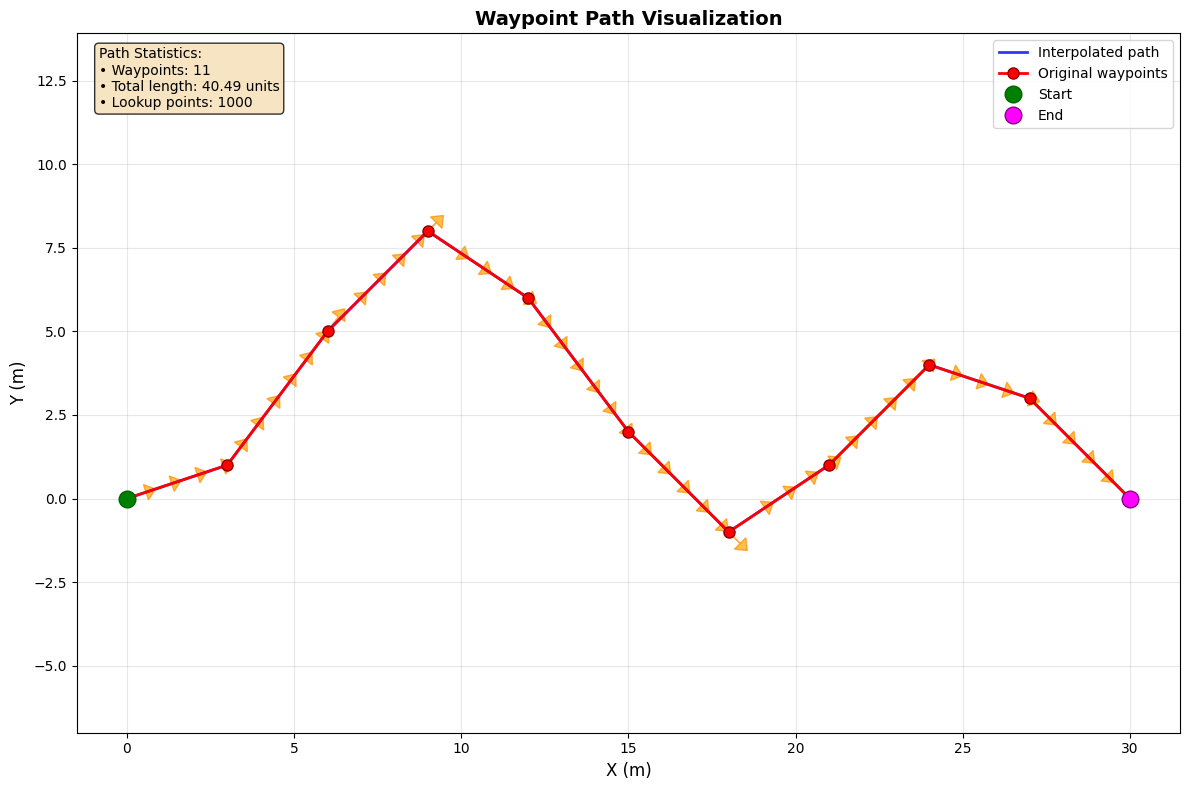

In [41]:
waypoints = np.array([
    [0, 0],
    [3, 1],
    [6, 5],
    [9, 8],
    [12, 6],
    [15, 2],
    [18, -1],
    [21, 1],
    [24, 4],
    [27, 3],
    [30, 0]
])
path = WaypointPathMPC(waypoints)
path.visualize_path()

In [42]:
opti = ca.Opti()

x = opti.variable(4, N+1) # type: ignore
u = opti.variable(3, N) # type: ignore
p = opti.parameter(4, 1) # type: ignore

# Cost function with MPCC errors
q_c = 100    # contouring error weight
q_l = 10   # lag error weight  
q_theta = 100  # progress weight
R = ca.diag([1, 1, 1000])  # control weights

for k in range(N):
    opti.subject_to(x[:, k+1] == F(x[:, k], u[:, k]))

cost = 0
for k in range(N):
    # Compute errors at each prediction step
    eps_c, eps_l = path.compute_path_errors(x[0,k], x[1,k], x[3,k])
    # MPCC cost
    cost += q_c * eps_c**2 + q_l * eps_l**2 - q_theta * x[3,k]
    cost += ca.mtimes([u[:,k].T, R, u[:,k]])

opti.minimize(cost)

opti.subject_to(x[:,0] == p)

# Set speed limit
opti.subject_to(u[0, :] <= 8)
opti.subject_to(u[0, :] >= 0)
opti.subject_to(u[1, :] <= 1)
opti.subject_to(u[1, :] >= -1)
opti.subject_to(u[2, :] > 0)
opti.subject_to(u[2, :] < 0.05)

# Theta limit
opti.subject_to(x[3, :] <= 1)
opti.subject_to(x[3, :] >= 0)

# Set initial condition
opti.subject_to(x[:,0] == p)
# opti.solver('worhp')
# opti.solver('sqpmethod')
opts = {
    'ipopt': {
        'print_level': 0,  # Just suppress output
        'sb': 'yes',
        'warm_start_init_point': 'yes',
    },
    'print_time': True
}
opti.solver('ipopt')
opti.set_value(p, ca.vertcat(0, 0, 0, 0))
sol = opti.solve()

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      168
Number of nonzeros in inequality constraint Jacobian.:       82
Number of nonzeros in Lagrangian Hessian.............:      130

Total number of variables............................:       74
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       48
Total number of inequality constraints...............:       82
        inequality constraints with only lower bounds:       41
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       41

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.7119972e-26 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

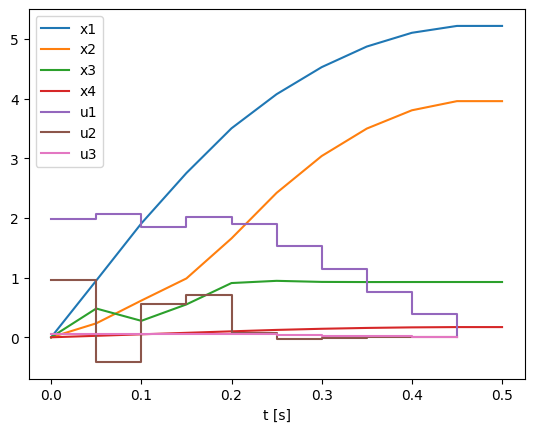

In [43]:
# Extract values from CasADi solution
x_vals = sol.value(x)  # Shape: (4, N) for 4 states
u_vals = sol.value(u)  # Shape: (3, N) for 3 inputs

tgrid = np.linspace(0, T*N, N+1)
plt.figure()
# Plot 3 states
plt.plot(tgrid, x_vals[0, :], label='x')
plt.plot(tgrid, x_vals[1, :], label='y') 
plt.plot(tgrid, x_vals[2, :], label='theta')
plt.plot(tgrid, x_vals[3, :], label='s')

# Plot 2 inputs as steps
plt.step(tgrid[:-1], u_vals[0, :], where='post', label='u1')
plt.step(tgrid[:-1], u_vals[1, :], where='post', label='u2')
plt.step(tgrid[:-1], u_vals[2, :], where='post', label='u3')

plt.xlabel('t [s]')
plt.legend(['x1', 'x2', 'x3','x4', 'u1', 'u2','u3'])

(np.float64(-0.2609258283029951),
 np.float64(5.479442394362898),
 np.float64(-0.1978944413482597),
 np.float64(4.155783268313454))

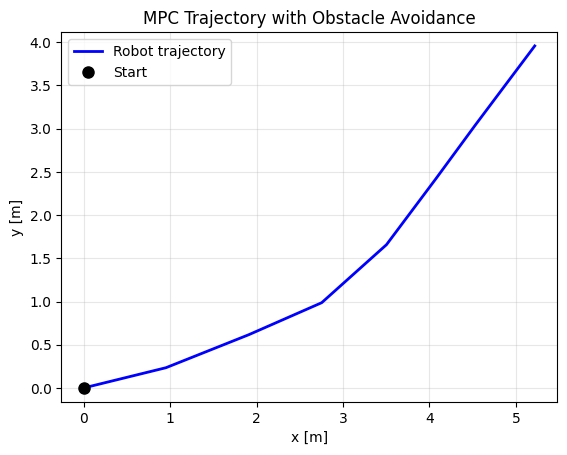

In [44]:
plt.figure()
plt.plot(x_vals[0, :], x_vals[1, :], 'b-', linewidth=2, label='Robot trajectory')

# Add start point
plt.plot(x_vals[0, 0], x_vals[1, 0], 'ko', markersize=8, label='Start')

plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('MPC Trajectory with Obstacle Avoidance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

In [45]:
M = opti.to_function('M',[p],[u[:,0]],['p'],['u_opt'])
M

Function(M:(p[4])->(u_opt[3]) MXFunction)

In [46]:
x_log = []
u_log = []

x = ca.vertcat(0, 0, 0, 0)


while(True):
    u = M(x)
    x_log.append(x)
    u_log.append(u)
    x = F(x, u)
    if (1 - x[3] < 0.001):
        break

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      168
Number of nonzeros in inequality constraint Jacobian.:       82
Number of nonzeros in Lagrangian Hessian.............:      130

Total number of variables............................:       74
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:       48
Total number of inequality constraints...............:       82
        inequality constraints with only lower bounds:       41
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:       41

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.7119972e-26 0.00e+00 1.00e+02  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

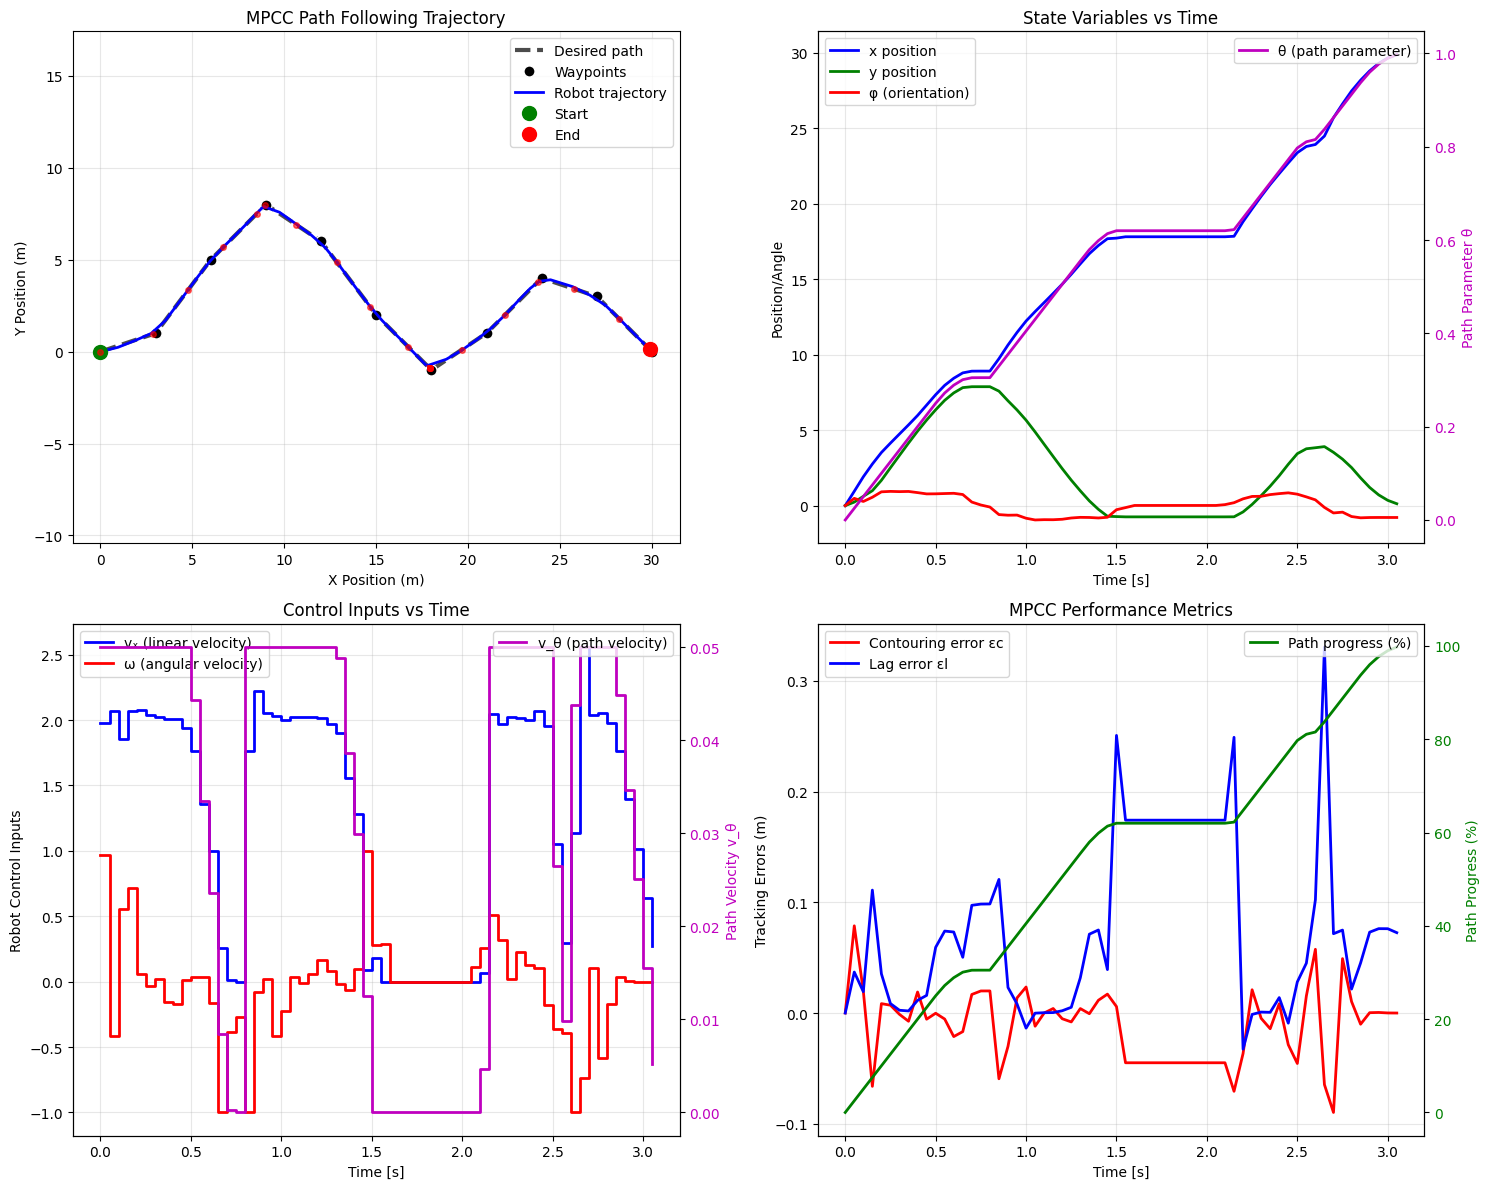


=== MPCC Simulation Results ===
Duration: 3.1 seconds
Final position: (29.87, 0.13) m
Path progress: 99.7% (θ = 0.997)
Final orientation: -0.785 rad (-45.0°)
Average contouring error: 0.0254 m
Max contouring error: 0.0898 m
RMS contouring error: 0.0341 m
Average lag error: 0.0782 m
Max lag error: 0.3306 m
RMS lag error: 0.1092 m
Average path velocity: 0.0323 1/s
Total distance traveled: 39.78 m
✓ Path successfully completed!


In [47]:
# Convert CasADi arrays to numpy for plotting
from matplotlib import patches
import numpy as np
import matplotlib.pyplot as plt

x_traj = np.array([np.array(x).flatten() for x in x_log])  # Shape: (N, 4) - now includes theta
u_traj = np.array([np.array(u).flatten() for u in u_log])  # Shape: (N, 3) - now includes v_theta

# Time vector
time_steps = np.arange(len(x_log)) * T

# Generate reference path for plotting using the waypoint path
theta_ref = np.linspace(0.001, 0.999, 200)
x_ref_path = [float(path.x_path_func(t)) for t in theta_ref]
y_ref_path = [float(path.y_path_func(t)) for t in theta_ref]

# Create comprehensive visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 1. Trajectory in 2D space with path following
ax1.plot(x_ref_path, y_ref_path, 'k--', linewidth=3, label='Desired path', alpha=0.7)

# Plot original waypoints
ax1.plot(path.original_waypoints[:, 0], path.original_waypoints[:, 1], 
         'ko', markersize=8, label='Waypoints', markerfacecolor='black', 
         markeredgecolor='white', markeredgewidth=1)

# Plot robot trajectory
ax1.plot(x_traj[:, 0], x_traj[:, 1], 'b-', linewidth=2, label='Robot trajectory')
ax1.plot(x_traj[0, 0], x_traj[0, 1], 'go', markersize=10, label='Start')
ax1.plot(x_traj[-1, 0], x_traj[-1, 1], 'ro', markersize=10, label='End')

# Show current path target points
target_interval = max(1, len(x_traj) // 20)
for i in range(0, len(x_traj), target_interval):
    theta_current = x_traj[i, 3]  # Current theta value
    x_target = float(path.x_path_func(theta_current))
    y_target = float(path.y_path_func(theta_current))
    ax1.plot(x_target, y_target, 'ro', markersize=4, alpha=0.6)
    ax1.plot([x_traj[i, 0], x_target], [x_traj[i, 1], y_target], 'r--', alpha=0.3)

# Add orientation arrows at regular intervals
arrow_interval = max(1, len(x_traj) // 10)
for i in range(0, len(x_traj), arrow_interval):
    x, y, phi = x_traj[i, :3]
    dx = 0.3 * np.cos(phi)
    dy = 0.3 * np.sin(phi)
    ax1.arrow(x, y, dx, dy, head_width=0.1, head_length=0.05, 
              fc='orange', ec='orange', alpha=0.7)

ax1.set_xlabel('X Position (m)')
ax1.set_ylabel('Y Position (m)')
ax1.set_title('MPCC Path Following Trajectory')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')

# 2. State variables over time (including theta)
ax2.plot(time_steps, x_traj[:, 0], 'b-', linewidth=2, label='x position')
ax2.plot(time_steps, x_traj[:, 1], 'g-', linewidth=2, label='y position')
ax2.plot(time_steps, x_traj[:, 2], 'r-', linewidth=2, label='φ (orientation)')
ax2_twin = ax2.twinx()
ax2_twin.plot(time_steps, x_traj[:, 3], 'm-', linewidth=2, label='θ (path parameter)')
ax2_twin.set_ylabel('Path Parameter θ', color='m')
ax2_twin.tick_params(axis='y', labelcolor='m')

ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Position/Angle')
ax2.set_title('State Variables vs Time')
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Control inputs over time (including v_theta)
ax3.step(time_steps, u_traj[:, 0], 'b-', linewidth=2, where='post', label='vₓ (linear velocity)')
ax3.step(time_steps, u_traj[:, 1], 'r-', linewidth=2, where='post', label='ω (angular velocity)')
ax3_twin = ax3.twinx()
ax3_twin.step(time_steps, u_traj[:, 2], 'm-', linewidth=2, where='post', label='v_θ (path velocity)')
ax3_twin.set_ylabel('Path Velocity v_θ', color='m')
ax3_twin.tick_params(axis='y', labelcolor='m')

ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Robot Control Inputs')
ax3.set_title('Control Inputs vs Time')
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. MPCC-specific metrics
# Compute contouring and lag errors using the waypoint path
eps_c_values = []
eps_l_values = []
path_progress = []

for i in range(len(x_traj)):
    x_pos, y_pos, phi_robot, theta_val = x_traj[i]
    
    # Compute errors using the waypoint path
    try:
        # Get path point and tangent angle at current theta
        x_path_val = float(path.x_path_func(theta_val))
        y_path_val = float(path.y_path_func(theta_val))
        phi_path_val = float(path.phi_path_func(theta_val))
        
        # Compute tracking errors
        dx = x_pos - x_path_val
        dy = y_pos - y_path_val
        
        # Contouring error (perpendicular to path)
        eps_c = np.sin(phi_path_val) * dx - np.cos(phi_path_val) * dy
        
        # Lag error (along path direction)
        eps_l = -np.cos(phi_path_val) * dx - np.sin(phi_path_val) * dy
        
        eps_c_values.append(eps_c)
        eps_l_values.append(eps_l)
        path_progress.append(theta_val * 100)  # Convert to percentage
        
    except Exception as e:
        print(f"Error computing tracking errors at step {i}: {e}")
        eps_c_values.append(np.nan)
        eps_l_values.append(np.nan)
        path_progress.append(theta_val * 100)

ax4.plot(time_steps, eps_c_values, 'r-', linewidth=2, label='Contouring error εc')
ax4.plot(time_steps, eps_l_values, 'b-', linewidth=2, label='Lag error εl')
ax4_twin = ax4.twinx()
ax4_twin.plot(time_steps, path_progress, 'g-', linewidth=2, label='Path progress (%)')
ax4_twin.set_ylabel('Path Progress (%)', color='g')
ax4_twin.tick_params(axis='y', labelcolor='g')

ax4.set_xlabel('Time [s]')
ax4.set_ylabel('Tracking Errors (m)')
ax4.set_title('MPCC Performance Metrics')
ax4.grid(True, alpha=0.3)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Print MPCC-specific statistics
eps_c_abs = np.abs(eps_c_values)
eps_l_abs = np.abs(eps_l_values)

print(f"\n=== MPCC Simulation Results ===")
print(f"Duration: {time_steps[-1]:.1f} seconds")
print(f"Final position: ({x_traj[-1, 0]:.2f}, {x_traj[-1, 1]:.2f}) m")
print(f"Path progress: {x_traj[-1, 3]*100:.1f}% (θ = {x_traj[-1, 3]:.3f})")
print(f"Final orientation: {x_traj[-1, 2]:.3f} rad ({np.degrees(x_traj[-1, 2]):.1f}°)")
print(f"Average contouring error: {np.nanmean(eps_c_abs):.4f} m")
print(f"Max contouring error: {np.nanmax(eps_c_abs):.4f} m")
print(f"RMS contouring error: {np.sqrt(np.nanmean(np.array(eps_c_values)**2)):.4f} m")
print(f"Average lag error: {np.nanmean(eps_l_abs):.4f} m")
print(f"Max lag error: {np.nanmax(eps_l_abs):.4f} m")
print(f"RMS lag error: {np.sqrt(np.nanmean(np.array(eps_l_values)**2)):.4f} m")
print(f"Average path velocity: {np.mean(u_traj[:, 2]):.4f} 1/s")
print(f"Total distance traveled: {np.sum(np.sqrt(np.diff(x_traj[:, 0])**2 + np.diff(x_traj[:, 1])**2)):.2f} m")

# Path completion analysis
if x_traj[-1, 3] >= 0.95:
    print("✓ Path successfully completed!")
else:
    print(f"⚠ Path incomplete - reached {x_traj[-1, 3]*100:.1f}% of total path")